# Проект по исследовательскому анализу данных (EDA)

## Содержание проекта: 
**1. Описание данных** 

**2. Загрузка данных, импорт библиотек** 

**3. Предобработка данных** 

**4. Исследовательский анализ данных** 

**5. Бизнес выводы и рекомендации** 

# **ОПИСАНИЕ ДАННЫХ**

**В таблице hotel_bookings представлены данные о бронированиях двух отелей - городского (City Hotel) и курортного (Resort Hotel). Содержится такая информация как: дата брони, число гостей, стоимость за ночь, число ночей, статусы заезда и отмены, наличие депозита, данные о гостях, число доп. запросов от потенциальных жильцов, наличие изменений в брони и другие характеристики.**
**Данные охватывают бронирования, совершенные в этих двух отелях с 01.07.2015 по 31.08.2017, включая отмененные и те, в которых гости не явились на заселение.**

### Какие закономерности есть в данных? Какие характеристики бронирования связаны с риском отмены и могут использоваться для раннего выявления потенциально отменяемых броней?

# **ЗАГРУЗКА ДАННЫХ**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
df = pd.read_csv('hotel_bookings.csv')
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


# **ПРЕДОБРАБОТКА ДАННЫХ**

#### В таблице содержатся мусор, дробные числа в колонках дискретного вида, пропущенные значения, которые нужно убрать для чистоты исследования.

In [88]:
df.isna().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

### Проверка данных на наличие дубликатов 

Найдено 31994 дублирующих строки (26,8% наблюдений). После удаления дубликатов количество наблюдений уменьшается с 119390 до 87396, а сancellation rate с 37% до 27%. 

Согласно описанию датасета, данные были взяты из реальной жизни, но обработаны и обезличены для возможности использования в учебных целях. 
Поэтому невозможно установить, являются ли идентичные строки повторными записями одной брони или несколькими различными бронированиями с одинаковыми характеристиками.

В своем проекте я буду использовать данные в исходном виде, не удаляя дублирующие строки, поскольку не могу однозначно определить их природу. 

In [89]:
print('Число дублирующих строк:', df.duplicated().sum())
print('Число строк после удаления дубликатов:', df.drop_duplicates().shape[0])

Число дублирующих строк: 31994
Число строк после удаления дубликатов: 87396


In [90]:
print('Cancellation rate полных данных (%):', df['is_canceled'].mean() * 100)
print('Cancellation rate данных с удаленными дубликатами (%):', df.drop_duplicates()['is_canceled'].mean() * 100)

Cancellation rate полных данных (%): 37.041628277075134
Cancellation rate данных с удаленными дубликатами (%): 27.489816467572886


## Проверка невалидных данных

Для agent и company пропуск интерпретируется как отсутствие указанного агента/компании, поэтому отдельная категория Unknown кодируется значением 0.
Исходный датасет содержит 119390 строк.
В 180 записях отсутствовали гости (adults + children + babies = 0), поэтому они были исключены как логически некорректные.

In [91]:
nan_replacements = {'children': 0.0, 'country': 'Unknown', 'agent': 0, 'company': 0}
data = df.fillna(nan_replacements)

In [92]:
(data['adults'] + data['children'] + data['babies'] == 0).sum()

np.int64(180)

In [93]:
data = data[(data['adults'] + data['children'] + data['babies']) > 0]

In [94]:
month_order = [
    'January', 'February', 'March', 'April',
    'May', 'June', 'July', 'August',
    'September', 'October', 'November', 'December'
]

months = {
    'January': 1,
    'February': 2,
    'March': 3,
    'April': 4,
    'May': 5,
    'June': 6,
    'July': 7,
    'August': 8,
    'September': 9,
    'October': 10,
    'November': 11,
    'December': 12
}

data['month_num'] = data['arrival_date_month'].map(months)

# **EDA - EXPLORATORY DATA ANALYSIS**

## Вопросы, на которые отвечает этот раздел

#### **1. Какие характеристики бронирований имеют наибольшую связь с отменой?** 
<details>
<summary>Нажмите, чтобы раскрыть</summary>

**Наиболее устойчиво связанные с отменой характеристики: lead time (число дней между датой совершения брони и датой предполагаемого заезда), тип депозита, наличие внесенных в бронирование изменений, наличие неотмененных (успешно завершенных) бронирований у этих гостей в прошлом, наличие специальных запросов к отелю.**
</details>

#### **2. Насколько сильно отличается риск между отелями?** 
<details>
<summary>Нажмите, чтобы раскрыть</summary>

**Риск отмены у отелей очень разный: сancellation rate для City hotel значительно выше, чем для Resort hotel (41,8% против 27,8%). Однако на отмену влияет множество признаков, такие как lead time (число дней между датой совершения брони и датой предполагаемого заезда), тип депозита, характеристики клиентов. Например, при наличии специальных запросов различия в cancellation rate между отелями становятся значительно меньше.**  
</details>


#### **3. Какие есть взаимодействия между признаками?** 
<details>
<summary>Нажмите, чтобы раскрыть</summary>

**Эффект lead time неодинаков для разных типов депозита. Наличие специальных запросов связано с более низким риском отмены, однако часть различий объясняется типом депозита и типом отеля.**
</details>

### Краткая справка о данных

После обработки таблица содержит 119210 бронирований. Каждая бронь имеет 33 характеристики (1 столбец с номером месяца был добавлен мной).

**Отменено 44199 броней.**

**Не отменено 75011 броней.**

**Общий сancellation rate = 37.1%**

Cancellation rate для **City hotel** = **41,8%**

Cancellation rate для **Resort hotel** = **27,8%**

In [95]:
print('Строк', data.shape[0], '| Cтолбцов', data.shape[1])

Строк 119210 | Cтолбцов 33


In [96]:
print('Доля отмененных броней (%):', len(data[data['is_canceled'] == 1])/len(data) * 100)
data['is_canceled'].value_counts()

Доля отмененных броней (%): 37.0765875346028


is_canceled
0    75011
1    44199
Name: count, dtype: int64

In [97]:
data.groupby('hotel', as_index=False)['is_canceled'].agg(
    total_bookings='count',
    canceled='sum',
    cancellation_rate='mean'
)

,hotel,total_bookings,canceled,cancellation_rate
0,City Hotel,79163,33079,0.417859
1,Resort Hotel,40047,11120,0.277674


### Сезонность и динамика отмен во времени в двух отелях



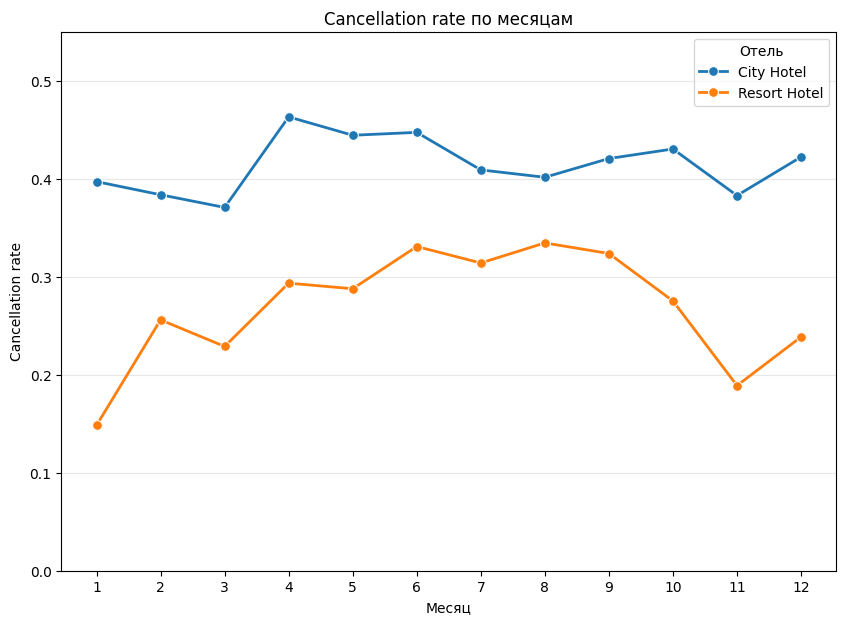

In [98]:
hotel_month_cancellation = data.groupby(['month_num', 'hotel'], as_index=False)['is_canceled'].mean()

plt.figure(figsize=(10, 7))

sns.lineplot(
    data=hotel_month_cancellation,
    x='month_num',
    y='is_canceled',
    hue='hotel',
    marker='o', 
    linewidth=2,   
    markersize=7  
)

plt.xticks(range(1, 13)) 
plt.ylim(0, 0.55)

plt.xlabel('Месяц')
plt.ylabel('Cancellation rate')
plt.title('Cancellation rate по месяцам')
plt.legend(title='Отель')

plt.grid(axis='y', alpha=0.3)
plt.show()

In [99]:
quantitative_cols = ['lead_time', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests']
string_cols = ['country', 'agent', 'company']
categorical_cols = ['hotel', 'arrival_date_year', 'arrival_date_month', 'meal', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type']
boolean_cols = ['is_repeated_guest']
target = ['is_canceled']

## Исследование числовых характеристик бронирования

### Выводы из описательных статистик количественных переменных в разрезе по отменам:

- У отмененных броней среднее время между бронированием и заездом (lead_time) выше. 
- У отмененных броней число предыдущих отмен (previous_cancellations) в среднем выше в 13 раз.
- У отмененных броней среднее число предыдущих неотмененных броней (previous_bookings_not_canceled) примерно в 8 раз ниже.
- У неотмененных броней среднее число изменений (booking_changes) примерно в 3 раза выше, чем у отмененных.
- Среднее количество дней в листе ожидания (days_in_waiting_list) у отменённых броней примерно в 2 раза выше, чем у неотмененных.
- Средняя стоимость номера за ночь (adr) у отмененных броней немного выше. 
- Среднее число парковочных мест (required_car_parking_spaces) выше у бронирований, которые не были отменены.

Ниже приведен подробный разбор каждого пункта.

In [100]:
data.groupby('is_canceled')[quantitative_cols].agg(['mean', 'median']).round(3).T

is_canceled                                  0        1
lead_time                      mean     80.082  144.886
                               median   45.000  113.000
stays_in_weekend_nights        mean      0.928    0.925
                               median    1.000    1.000
stays_in_week_nights           mean      2.462    2.562
                               median    2.000    2.000
adults                         mean      1.834    1.903
                               median    2.000    2.000
children                       mean      0.103    0.107
                               median    0.000    0.000
babies                         mean      0.010    0.004
                               median    0.000    0.000
previous_cancellations         mean      0.016    0.208
                               median    0.000    0.000
previous_bookings_not_canceled mean      0.203    0.025
                               median    0.000    0.000
booking_changes                mean      0.290    0.098
                               median    0.000    0.000
days_in_waiting_list           mean      1.588    3.566
                               median    0.000    0.000
adr                            mean    100.169  105.024
                               median   92.700   96.300
required_car_parking_spaces    mean      0.099    0.000
                               median    0.000    0.000
total_of_special_requests      mean      0.714    0.329
                               median    1.000    0.000

### Расчет доли отмен в общем числе броней у клиентов с разным числом дней между датой создания брони и заездом:  

Lead time разбит на категории (бакеты) по 20 дней (0-20, 21-40 и тд).    
Cancellation Rate = Число отмен / Все брони 
ИЛИ среднее от is_canceled, так как 1 отвечает за отмену, а 0 за ее отсутствие.

Из результатов видно, что гипотеза подтверждается: наблюдается сильная положительная связь между числом дней между заездом и бронью и последующей отменой, особенно после 100 дней. Например, при lead_time 20-40 дней отменяется около 34.6% броней, а при lead_time 340-360 дней — около 72.8%. При крайне высоких lead_time часто cancellation_rate=1 (бронирований с такими показателями немного и все они были отменены). На очень долгие промежутки ориентироваться не стоит, средний lead_time 104 дня, а медиана 69 дней. Для простоты восприятия отфильтровала бакеты, в которых меньше 100 наблюдений.

In [101]:
print('Число броней с заездом в тот же день (lead_time = 0)')
data[data['lead_time'] == 0].shape[0]

Число броней с заездом в тот же день (lead_time = 0)


6264

In [102]:
data['lead_bucket'] = pd.cut(data['lead_time'],
                             bins=[-1] + list(range(20, 741, 20)))

lead_stats = (
    data.groupby('lead_bucket', as_index=False)['is_canceled']
        .agg(
            total_bookings='count',
            canceled='sum',
            cancelation_rate = 'mean'
        )
)

lead_stats = lead_stats[lead_stats['total_bookings'] >= 100].copy()

lead_stats

,lead_bucket,total_bookings,canceled,cancelation_rate
0,"(-1, 20]",31725,4891,0.154169
1,"(20, 40]",13653,4724,0.346005
2,"(40, 60]",10154,3727,0.367047
3,"(60, 80]",8792,3499,0.397975
4,"(80, 100]",7556,3147,0.416490
5,"(100, 120]",6658,2966,0.445479
6,"(120, 140]",5587,2336,0.418113
7,"(140, 160]",5280,2383,0.451326
8,"(160, 180]",5124,2455,0.479118
9,"(180, 200]",4044,1863,0.460682


### Lead time в разрезе разных отелей

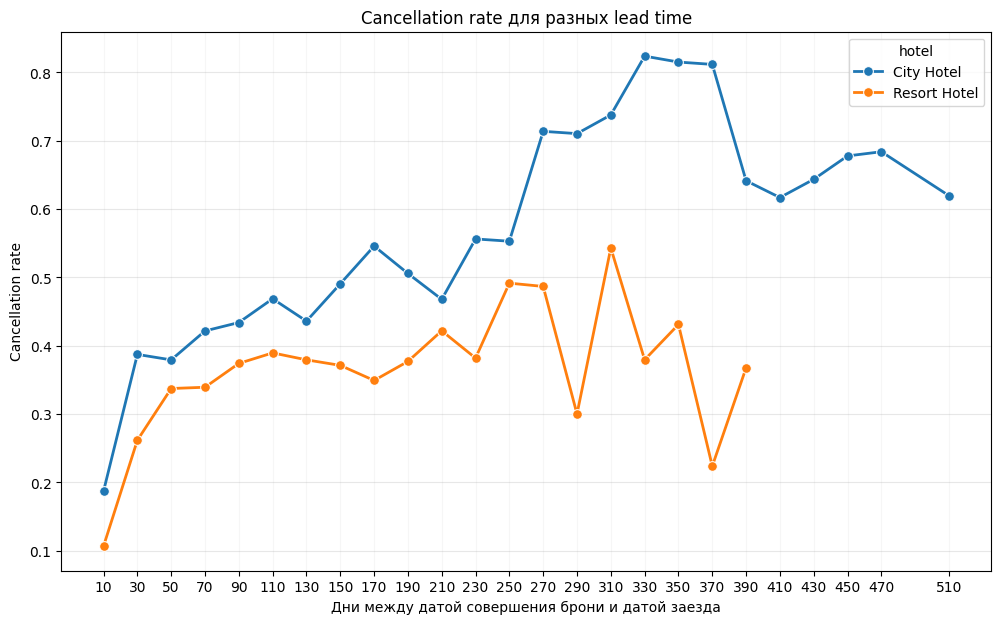

In [103]:
lead_hotel_stats = (
    data.groupby(['lead_bucket', 'hotel'], as_index=False)['is_canceled']
        .agg(
            total_bookings='count',
            canceled='sum',
            cancellation_rate = 'mean'
        )
)

lead_hotel_stats['lead_mid'] = lead_hotel_stats['lead_bucket'].apply(
    lambda x: x.mid.round()
)

lead_hotel_stats = lead_hotel_stats[lead_hotel_stats['total_bookings'] >= 100].copy()


plt.figure(figsize=(12,7))

sns.lineplot(
    data=lead_hotel_stats, 
    x='lead_mid',
    y='cancellation_rate',
    hue='hotel',
    marker='o',
    linewidth=2,
    markersize=7
)

plt.xticks(lead_hotel_stats['lead_mid'].unique())
plt.title('Cancellation rate для разных lead time')
plt.xlabel('Дни между датой совершения брони и датой заезда')
plt.ylabel('Cancellation rate')
plt.grid(axis='y', alpha=0.3)
plt.grid(axis='x', alpha=0.1)

plt.show()

### О связи отмены в настоящем с отменами в прошлом 

Брони клиентов с историей предыдущих отмен в целом чаще отменяются. Особенно высокая доля отмен наблюдается при большом количестве предыдущих отмен, однако для таких значений количество наблюдений небольшое, поэтому результаты нужно интерпретировать с осторожностью.

In [104]:
data.groupby('previous_cancellations', as_index=False)['is_canceled'] \
    .agg(
        bookings='count',
        canceled='sum',
        cancellation_rate='mean').head(20)

,previous_cancellations,bookings,canceled,cancellation_rate
0,0,112731,38259,0.339383
1,1,6048,5712,0.944444
2,2,114,38,0.333333
3,3,65,20,0.307692
4,4,31,7,0.225806
5,5,19,2,0.105263
6,6,22,7,0.318182
7,11,35,10,0.285714
8,13,12,11,0.916667
9,14,14,14,1.000000


### О связи отмен и успешно завершенных броней в прошлом 

Наличие успешно завершённых броней в прошлом связано с более низкой долей отмен: 38.1% при отсутствии таких броней против примерно 5,5% при наличии 1-9 предыдущих броней.

In [105]:
data.groupby('previous_bookings_not_canceled', as_index=False)['is_canceled'] \
    .agg(bookings='count', 
         canceled='sum', 
         cancellation_rate='mean') \
    .head(20)

,previous_bookings_not_canceled,bookings,canceled,cancellation_rate
0,0,115597,43999,0.380624
1,1,1538,79,0.051365
2,2,580,32,0.055172
3,3,333,17,0.051051
4,4,229,12,0.052402
5,5,181,11,0.060773
6,6,113,3,0.026549
7,7,88,5,0.056818
8,8,70,3,0.042857
9,9,59,0,0.000000


In [106]:
data['previous_successful_booking'] = (
    data['previous_bookings_not_canceled'] > 0).astype(int)

data.groupby('previous_successful_booking', as_index=False)['is_canceled'] \
    .agg(bookings='count', 
         cancellation_rate='mean')

,previous_successful_booking,bookings,cancellation_rate
0,0,115597,0.380624
1,1,3613,0.055356


### Об изменениях в брони

Большинство клиентов вообще не вносят изменений в бронирование (booking_changes = 0). При этом среди таких клиентов доля отмен составляет около 41%. Как только в бронирование вносится хотя бы одно изменение, доля отмен резко снижается примерно до 14%. При дальнейшем увеличении числа изменений она остается значительно ниже исходного уровня, колеблясь примерно в диапазоне 10–30%.

Это может свидетельствовать о том, что клиенты, которые вносят изменения в бронирование, в среднем сильнее заинтересованы в предстоящем проживании и с большей вероятностью действительно планируют заселиться. Однако по этим данным нельзя утверждать о причинно-следственной связи: возможно, на вероятность отмены влияют другие характеристики таких клиентов или их бронирований. 

Также важным моментом является то, что эту характеристику бронирования нельзя использовать для предсказания ранней отмены (при оформлении бронирования), так как изменения могут происходить только после создания брони. 

In [107]:
data.groupby('booking_changes', as_index=False)['is_canceled'] \
        .agg(
            total_bookings='count',
            canceled='sum',
            cancellation_rate = 'mean'
        )

,booking_changes,total_bookings,canceled,cancellation_rate
0,0,101232,41369,0.408655
1,1,12666,1804,0.142429
2,2,3780,766,0.202646
3,3,914,144,0.157549
4,4,367,67,0.182561
5,5,115,20,0.173913
6,6,61,18,0.295082
7,7,29,3,0.103448
8,8,14,4,0.285714
9,9,8,1,0.125000


### О связи отмен и числа запросов к отелю 

Наличие специальных запросов связано со значительно более низким риском отмены. У бронирований, в которых гости у отеля ничего дополнительного не запрашивали (total_of_special_requests = 0), cancellation rate выше и составляет 47,8%. У нас есть достаточно много наблюдений в случае одного и двух запросов к отелю, чтобы мы могли их рассматривать. В них cancellation rate более чем в 2 раза ниже, чем в бронях без запросов (22% против 47,8%). При дальнейшем увеличении числа запросов cancellation rate продолжает снижаться, однако для 3+ запросов объём наблюдений существенно меньше.

In [108]:
data.groupby('total_of_special_requests', as_index=False)['is_canceled'] \
        .agg(
            total_bookings='count',
            canceled='sum',
            cancellation_rate = 'mean'
        )

,total_of_special_requests,total_bookings,canceled,cancellation_rate
0,0,70201,33534,0.477686
1,1,33183,7316,0.220474
2,2,12952,2866,0.221279
3,3,2494,445,0.178428
4,4,340,36,0.105882
5,5,40,2,0.050000


### О связи отмен и цен за ночь 

На графике boxplot показано распределение цен за ночь (adr) у отмененных и неотмененных бронирований. Для наглядности отображены значения до 99-го процентиля, поскольку в данных присутствуют экстремально высокие значения, которые затрудняют сравнение распределений.
Медианы и квартили (Q1, Q3) в обеих группах близки, поэтому существенных различий в стоимости номера за ночь между отменёнными и неотменёнными бронированиями не наблюдается.

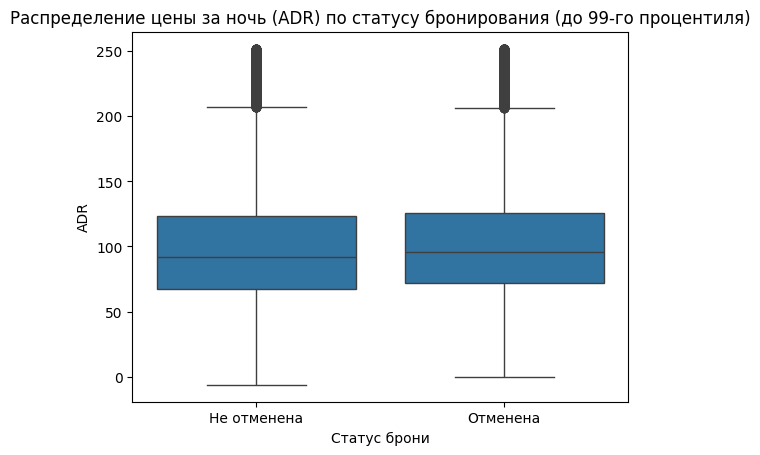

In [109]:
adr_quantile99 = data['adr'].quantile(0.99)

sns.boxplot(
    data=data[data['adr'] <= adr_quantile99],
    x='is_canceled',
    y='adr'
)

plt.xlabel('Статус брони')
plt.ylabel('ADR')
plt.xticks([0, 1], ['Не отменена', 'Отменена'])
plt.title('Распределение цены за ночь (ADR) по статусу бронирования (до 99-го процентиля)')
plt.show()

### О связи отмен и потребности в парковочных местах

Брони, для которых требовалось хотя бы одно парковочное место, не имели отмен: cancellation rate составил 0% против 39.5% для броней без необходимости в парковочном месте. При этом почти 94% бронирований вообще не требовали парковки, поэтому результат стоит интерпретировать с осторожностью из-за особенностей распределения признака. 

In [110]:
car_parking_spaces = (
    data.groupby('required_car_parking_spaces', as_index=False)['is_canceled']
        .agg(
            total_bookings='count',
            canceled='sum',
            cancellation_rate = 'mean'
        )
)

car_parking_spaces

,required_car_parking_spaces,total_bookings,canceled,cancellation_rate
0,0,111801,44199,0.395336
1,1,7376,0,0.000000
2,2,28,0,0.000000
3,3,3,0,0.000000
4,8,2,0,0.000000


### О связи отмен и числом дней в ожидании подтверждения бронирования

При наличии дней ожидания cancellation rate заметно выше, особенно для интервала 8-30 дней. Однако бакет в 0 дней ожидания содержит почти 97% бронирований, что не позволяет делать достоверных выводов о других интервалах, они слишком малы и подвержены случайностям.

In [111]:
(data['days_in_waiting_list'] > 0).mean()

np.float64(0.030978944719402733)

In [112]:
bins = [-1, 0, 1, 7, 30, float('inf')]
labels = ['0', '1', '2–7', '8–30', '31+']

data['waiting_list_bucket'] = pd.cut(
    data['days_in_waiting_list'],
    bins=bins,
    labels=labels
)

In [113]:
data.groupby('waiting_list_bucket', as_index=False)['is_canceled'].agg(
    bookings='count',
    canceled='sum',
    cancellation_rate='mean'
)

,waiting_list_bucket,bookings,canceled,cancellation_rate
0,0,115517,41840,0.362198
1,1,12,3,0.250000
2,2–7,116,76,0.655172
3,8–30,463,368,0.794816
4,31+,3102,1912,0.616377


## Исследование категориальных характеристик

### О связи между типом депозита и отменами

99,3% бронирований с невозвратным депозитом были отменены. 

In [114]:
data.groupby('deposit_type')['is_canceled'].agg(
    total_bookings='count',
    canceled='sum',
    cancellation_rate='mean'
)

,total_bookings,canceled,cancellation_rate
deposit_type,,,
No Deposit,104461,29669,0.284020
Non Refund,14587,14494,0.993624
Refundable,162,36,0.222222


### Исследование цен за ночь в контексте типов депозита

По сравнению с бронированиями без депозита у невозвратных бронирований ниже как медиана стоимости номера за ночь (adr) (86 против 104), так и среднее стоимости за ночь (90 против 112). 

Максимальное значение цены за ночь у броней с невозвратным депозитом (5400) в несколько раз превышает среднее (90) и является экстремальным значением (выбросом). Чтобы снизить влияние этого значения на анализ распределения цен, для бронирований с типом депозита Non Refund исключим значения выше 99-го процентиля. 

Значения adr=0 встречаются в 1810 наблюдениях и требуют отдельной интерпретации; они не были автоматически удалены, поскольку могут отражать реальные особенности бронирования.

In [115]:
print('\nОписательные статистики цены за ночь (adr) у броней с разными типами депозита:\n')

adr_99_nonrefund = data[(data['adr'] <= adr_quantile99) & (data['deposit_type'] == 'Non Refund')]['adr']

deposit_stats_adr = pd.DataFrame({
    'No Deposit': data[
        (data['deposit_type'] == 'No Deposit') &
        (data['is_canceled'] == 1)
    ]['adr'].describe().round(2),

    'Non Refund': data[
        (data['deposit_type'] == 'Non Refund') &
        (data['is_canceled'] == 1)
    ]['adr'].describe().round(2),

    'Non Refund 99%': adr_99_nonrefund.describe().round(2),

    'Refundable': data[
        (data['deposit_type'] == 'Refundable') &
        (data['is_canceled'] == 1)
    ]['adr'].describe().round(2)
})

deposit_stats_adr


Описательные статистики цены за ночь (adr) у броней с разными типами депозита:



,No Deposit,Non Refund,Non Refund 99%,Refundable
count,29669.00,14494.00,14585.00,36.00
mean,112.34,90.04,89.58,102.72
std,50.45,53.49,30.22,57.74
min,0.00,6.00,6.00,8.00
25%,78.00,62.80,62.80,47.50
50%,104.40,86.00,86.00,99.00
75%,138.38,110.00,110.00,139.50
max,450.00,5400.00,250.00,230.00


In [116]:
print('\nЧисло бронирований с нулевой ценой за ночь:')
data[data['adr'] == 0].shape[0]


Число бронирований с нулевой ценой за ночь:


1810

### Тип депозита имеет значительно более сильную связь с отменой, чем ADR

Для бронирований Non Refund наблюдается сancellation rate стабильно около 99% практически во всех ценовых диапазонах.
Для бронирований No Deposit при ADR > 0 наблюдается положительная связь между стоимостью номера и вероятностью отмены вплоть до диапазона 250–300 у.е. 

In [117]:
bins = [-1, 0, 50, 100, 150, 200, 250, 300, 350, 400, 450]

data['adr_bucket'] = pd.cut(data['adr'], bins=bins)

non_refund = data[data['deposit_type'] == 'Non Refund'] \
                .groupby('adr_bucket', as_index=False)['is_canceled'] \
                .agg(
                    cancellation_rate='mean', 
                    bookings='count'
                )

non_refund

,adr_bucket,cancellation_rate,bookings
0,"(-1, 0]",NaN,0
1,"(0, 50]",0.981785,549
2,"(50, 100]",0.993809,9691
3,"(100, 150]",0.994297,3682
4,"(150, 200]",0.998415,631
5,"(200, 250]",0.968750,32
6,"(250, 300]",NaN,0
7,"(300, 350]",1.000000,1
8,"(350, 400]",NaN,0
9,"(400, 450]",NaN,0


In [118]:
no_deposit = data[data['deposit_type'] == 'No Deposit'] \
                .groupby('adr_bucket', as_index=False)['is_canceled'] \
                .agg(
                    cancellation_rate='mean', 
                    bookings='count'
                )

no_deposit 

,adr_bucket,cancellation_rate,bookings
0,"(-1, 0]",0.103867,1810
1,"(0, 50]",0.188432,9457
2,"(50, 100]",0.262535,45811
3,"(100, 150]",0.318711,31549
4,"(150, 200]",0.343753,10941
5,"(200, 250]",0.383014,3650
6,"(250, 300]",0.385331,968
7,"(300, 350]",0.306306,222
8,"(350, 400]",0.333333,45
9,"(400, 450]",0.500000,4


### Исследование топ-10 стран по числу бронирований 

Рассматриваю только страны с наибольшим числом бронирований, чтобы исключить нестабильные результаты для очень маленьких групп. 
Гости из Португалии оформили 40,7% от общего числа бронирований. Португалия имеет наибольший cancellation rate в 56,7%. Из описания датасета известно, что оба отеля находятся в Португалии, чем может объясняться число гостей.

In [119]:
data.groupby('country', as_index=False)['is_canceled'] \
    .agg(
        bookings='count', 
        cancellation_rate='mean'
    ).sort_values('bookings', ascending=False) \
     .head(10)

,country,bookings,cancellation_rate
135,PRT,48483,0.567333
59,GBR,12120,0.202310
56,FRA,10401,0.185848
51,ESP,8560,0.254322
43,DEU,7285,0.167193
81,ITA,3761,0.354427
76,IRL,3374,0.246592
15,BEL,2342,0.202391
25,BRA,2222,0.373537
123,NLD,2103,0.184023


## Взаимосвязи различных характеристик

### Взаимосвязь отмен, типа депозита и типа отеля 

Большая часть невозвратных бронирований (88,2%) приходится на городской отель. Cancellation rate для No deposit типов броней у двух отелей довольно близок (30,5% против 24,7%), как и Non refund (99,8% против 96%). Resort отель в обоих случаях имеет меньшие показатели. 

In [120]:
data.groupby(['hotel', 'deposit_type'], as_index=False)['is_canceled'].agg(
    total_bookings='count',
    canceled='sum',
    cancellation_rate='mean'
)

,hotel,deposit_type,total_bookings,canceled,cancellation_rate
0,City Hotel,No Deposit,66275,20221,0.305108
1,City Hotel,Non Refund,12868,12844,0.998135
2,City Hotel,Refundable,20,14,0.700000
3,Resort Hotel,No Deposit,38186,9448,0.247421
4,Resort Hotel,Non Refund,1719,1650,0.959860
5,Resort Hotel,Refundable,142,22,0.154930


### Взаимосвязь отмен, типа депозита и срока от даты совершения брони до даты заезда (lead time)

Удаление записей, где для каждого 20-дневного периода присутствует меньше 100 бронирований, полностью исключает тип депозита Refundable, так как таких броней всего 162 за все время наблюдений.

Для бронирований с Non Refund типом депозита cancellation rate практически не зависит от lead time и на большинстве интервалов близок к 99%. Для No deposit бронирований cancellation rate заметно ниже и возрастает с увеличение срока между совершением брони и датой заезда, однако после промежутка 240-260 дней начинаются сильные колебания (связываю их с меньшим числом наблюдений). 
Размер точки на графике отображает размер группы по наблюдениям.

**Связь между lead time и cancellation rate зависит от типа депозита.**

In [121]:
lead_deposit_stats = data.groupby(['deposit_type', 'lead_bucket'], as_index=False)['is_canceled'] \
    .agg(
        bookings='count',
        canceled='sum',
        cancellation_rate='mean'
    )

lead_deposit_stats = lead_deposit_stats[lead_deposit_stats['bookings'] >= 100].copy()
lead_deposit_stats

,deposit_type,lead_bucket,bookings,canceled,cancellation_rate
0,No Deposit,"(-1, 20]",31354,4577,0.145978
1,No Deposit,"(20, 40]",12990,4068,0.313164
2,No Deposit,"(40, 60]",9554,3131,0.327716
3,No Deposit,"(60, 80]",7786,2496,0.320575
4,No Deposit,"(80, 100]",6655,2249,0.337941
5,No Deposit,"(100, 120]",5613,1922,0.342419
6,No Deposit,"(120, 140]",4977,1726,0.346795
7,No Deposit,"(140, 160]",4403,1508,0.342494
8,No Deposit,"(160, 180]",3955,1400,0.353982
9,No Deposit,"(180, 200]",3436,1260,0.366705


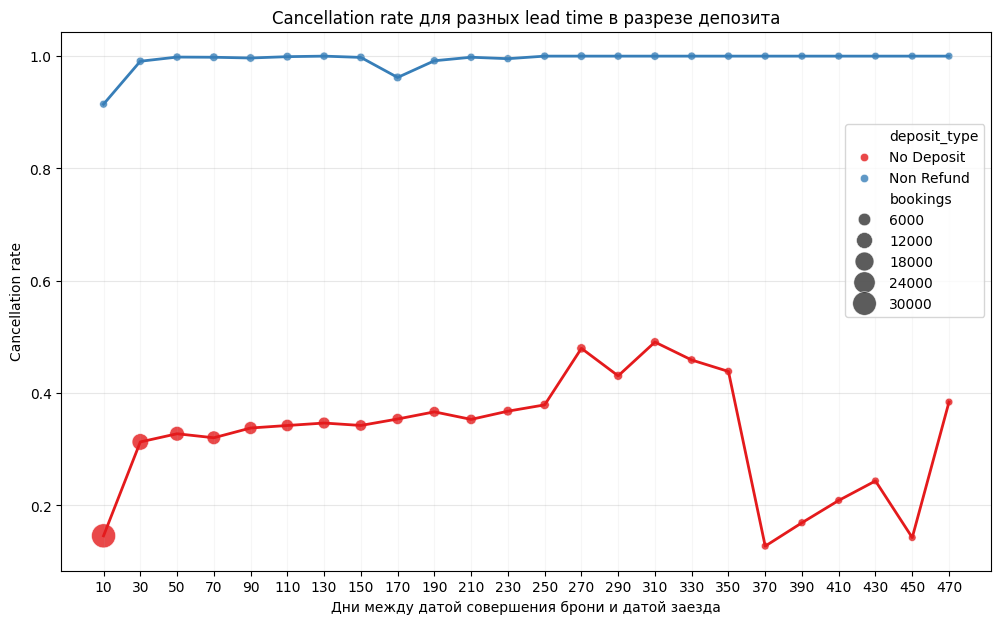

In [122]:
lead_deposit_stats['lead_mid'] = lead_deposit_stats['lead_bucket'].apply(
    lambda x: x.mid.round()
)


plt.figure(figsize=(12,7))

sns.lineplot(
    data=lead_deposit_stats, 
    x='lead_mid',
    y='cancellation_rate',
    hue='deposit_type',
    linewidth=2,
    markersize=7,
    palette='Set1',
    legend=False 
)

sns.scatterplot(
    data=lead_deposit_stats,
    x='lead_mid',
    y='cancellation_rate',
    hue='deposit_type',
    size='bookings',
    sizes=(30, 300),
    alpha=0.8, 
    legend='brief',
    palette='Set1'
)

plt.xticks(lead_deposit_stats['lead_mid'].unique())
plt.title('Cancellation rate для разных lead time в разрезе депозита')
plt.xlabel('Дни между датой совершения брони и датой заезда')
plt.ylabel('Cancellation rate')
plt.grid(axis='y', alpha=0.3)
plt.grid(axis='x', alpha=0.1)
plt.legend(loc='center right', bbox_to_anchor=(1, 0.65))

plt.show()

### Взаимосвязь отмен, типа депозита и наличия специальных запросов к отелю

Рассмотрим невозвратный тип депозита (Non Refund). 99,8% бронирований, приходящихся на этот тип депозита, не имеют дополнительных запросов к отелю. Такие бронирования имеют cancellation rate 99,4%. Рассматривать брони с таким депозитом, имеющие 1 или 2 запроса, нет смысла из-за критически малого размера выборки (меньше 1%). Ранее было обнаружено, что наличие специальных запросов связано с более низким риском отмены. Эта связь сохраняется внутри наиболее массовой категории No Deposit: cancellation rate составляет 34,3% для бронирований без запросов и около 22% для бронирований с 1-2 запросами.

In [123]:
data.groupby(['total_of_special_requests', 'deposit_type'], as_index=False)['is_canceled'] \
        .agg(
            total_bookings='count',
            canceled='sum',
            cancellation_rate = 'mean'
        )

,total_of_special_requests,deposit_type,total_bookings,canceled,cancellation_rate
0,0,No Deposit,55494,19037,0.343046
1,0,Non Refund,14563,14476,0.994026
2,0,Refundable,144,21,0.145833
3,1,No Deposit,33147,7287,0.219839
4,1,Non Refund,22,18,0.818182
5,1,Refundable,14,11,0.785714
6,2,No Deposit,12947,2863,0.221132
7,2,Non Refund,2,0,0.000000
8,2,Refundable,3,3,1.000000
9,3,No Deposit,2493,444,0.178099


### Взаимосвязь отмен, типа отеля и наличия специальных запросов к отелю

Разница в cancellation rate между отелями в основном наблюдается среди бронирований без специальных запросов. Для таких бронирований cancellation rate в City Hotel составляет 55% против 32,3% в Resort Hotel. Однако среди бронирований с 1–3 специальными запросами cancellation rate в двух отелях практически совпадает. 

In [124]:
data.groupby(['total_of_special_requests', 'hotel'], as_index=False)['is_canceled'] \
        .agg(
            total_bookings='count',
            canceled='sum',
            cancellation_rate = 'mean'
        )

,total_of_special_requests,hotel,total_bookings,canceled,cancellation_rate
0,0,City Hotel,47853,26320,0.550018
1,0,Resort Hotel,22348,7214,0.322803
2,1,City Hotel,21377,4719,0.220751
3,1,Resort Hotel,11806,2597,0.219973
4,2,City Hotel,8125,1739,0.214031
5,2,Resort Hotel,4827,1127,0.233478
6,3,City Hotel,1584,279,0.176136
7,3,Resort Hotel,910,166,0.182418
8,4,City Hotel,198,21,0.106061
9,4,Resort Hotel,142,15,0.105634


# Ключевые выводы исследовательского блока 

**1. 37.1% бронирований были отменены.** 

**2. Риск отмены существенно различается между типами отелей. City Hotel имеет cancellation rate 41.8% против 27.8% у Resort Hotel. При этом различие между отелями зависит и от других характеристик бронирования.** 

**3. В данных наблюдается устойчивая связь между lead time и cancellation rate. При увеличении срока между бронированием и заездом риск отмены растёт, особенно для бронирований без депозита.**

**4. Тип депозита Non Refund особенно сильно связан с отменами.** 

**5. Эффект lead time неодинаков для разных типов депозитов.**

**6. Наличие изменений в бронировании связано с меньшим cancellation rate.** 

**7. Предыдущие успешно завершенные бронирования сильно связаны с меньшим риском отмены.** 

**8. Сезонность и цена номера за ночь имеют слабую связь с cancellation rate.** 

**9. Наличие специальных запросов связано с более низким риском отмены. Однако часть различий объясняется типом депозита: почти все бронирования с Non Refund не содержат специальных запросов.**

# Рекомендации и возможные бизнес-применения

#### Для минимизации рисков отмены отель потенциально может: 
- Выделять новые бронирования с высоким lead time в группу повышенного риска, учитывать их повышенную вероятность отмены при планировании загрузки.
- Для проверенных клиентов сохранять максимально простой процесс бронирования.
- Для новых клиентов при наличии других признаков риска использовать дополнительные напоминания или более строгие условия тарифа.
- Использовать тип депозита как один из ключевых факторов сегментации.
- Рассмотреть дополнительные механизмы для дополнительных подтверждений, напоминаний и возможностей для переноса дат для гостей с высоким риском.
- Использовать специальные запросы как дополнительные сигналы вовлечённости гостя.
- Учитывать разницу между отелями и не использовать единую стратегию для обоих типов отеля.
- Построить модель прогнозирования как следующий этап, если есть задача автоматизировать оценку риска. При этом в модель раннего прогнозирования должны попадать только признаки, доступные в момент создания бронирования.

#### **Результаты EDA рекомендуется использовать для сегментации бронирований, более эффективной коммуникации и управления риском загрузки. На следующем этапе эффективность конкретных вмешательств следует проверять с помощью A/B-тестирования, а затем автоматизировать оценку индивидуального риска с помощью предсказательных моделей.**